# Fake News Classification — Exploratory Data Analysis (EDA)

Dataset: `dataset/data.csv` — columns: `label` (0=fake, 1=real), `title`, `text`, `subject`, `date`

Goal of this notebook: understand the data, check class balance and data leakage before deciding which columns to use
as model features (see conclusions at the end).


## 1. Setup

In [1]:
import os
os.chdir('../')
print(os.getcwd())

c:\Users\kriti\Dropbox\PC\Desktop\Ironhack_AI_Engineering\Projects\Project_2\Project-2-Natural-Language-Processing


In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dataset/data.csv')
print(df.shape)
df.head()

(39942, 5)


,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## 2. Data Overview

In [4]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.info()

Shape: (39942, 5)

Missing values:
 label      0
title      0
text       0
subject    0
date       0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 39942 entries, 0 to 39941
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    39942 non-null  int64
 1   title    39942 non-null  str  
 2   text     39942 non-null  str  
 3   subject  39942 non-null  str  
 4   date     39942 non-null  str  
dtypes: int64(1), str(4)
memory usage: 96.7 MB


## 3. Label Distribution

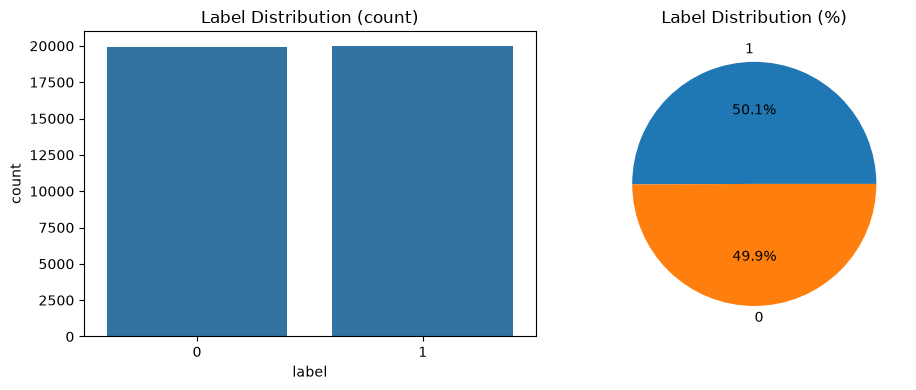

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='label', data=df, ax=ax[0])
ax[0].set_title('Label Distribution (count)')

df['label'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%', ax=ax[1], ylabel=''
)
ax[1].set_title('Label Distribution (%)')

plt.tight_layout()
plt.show()


## 4. Subject Distribution — Leakage Check

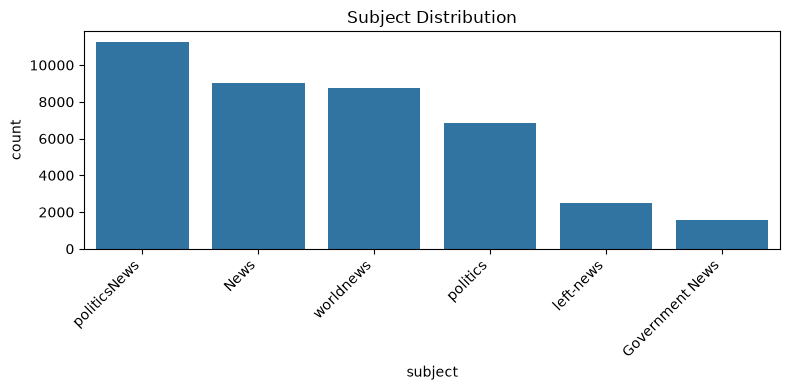

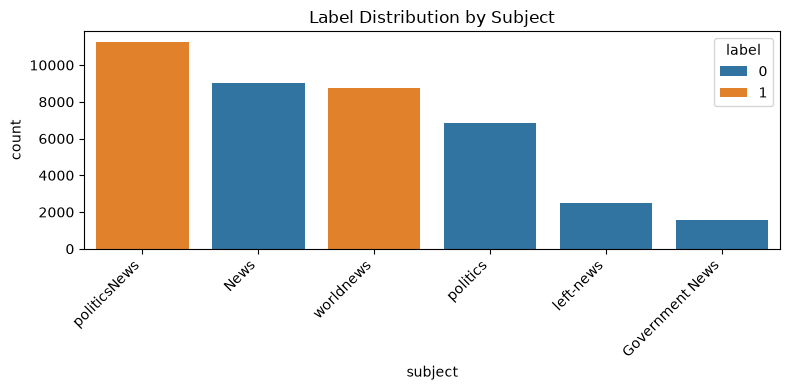

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(x='subject', data=df, order=df['subject'].value_counts().index)
plt.title('Subject Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Label distribution across subjects
plt.figure(figsize=(8, 4))
sns.countplot(x='subject', hue='label', data=df, order=df['subject'].value_counts().index)
plt.title('Label Distribution by Subject')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [7]:
pd.crosstab(df['subject'], df['label'])


label,0,1
subject,,
Government News,1570,0
News,9050,0
left-news,2482,0
politics,6841,0
politicsNews,0,11272
worldnews,0,8727


**Finding:** there is a clear data leak in this column — several subjects map almost
entirely to a single label.

## 5. Date Distribution — Leakage Check

Convert `date` to datetime and check whether fake/real news cluster into distinct
time periods (another possible leakage source), and how many dates fail to parse.

Unparseable dates: 19943


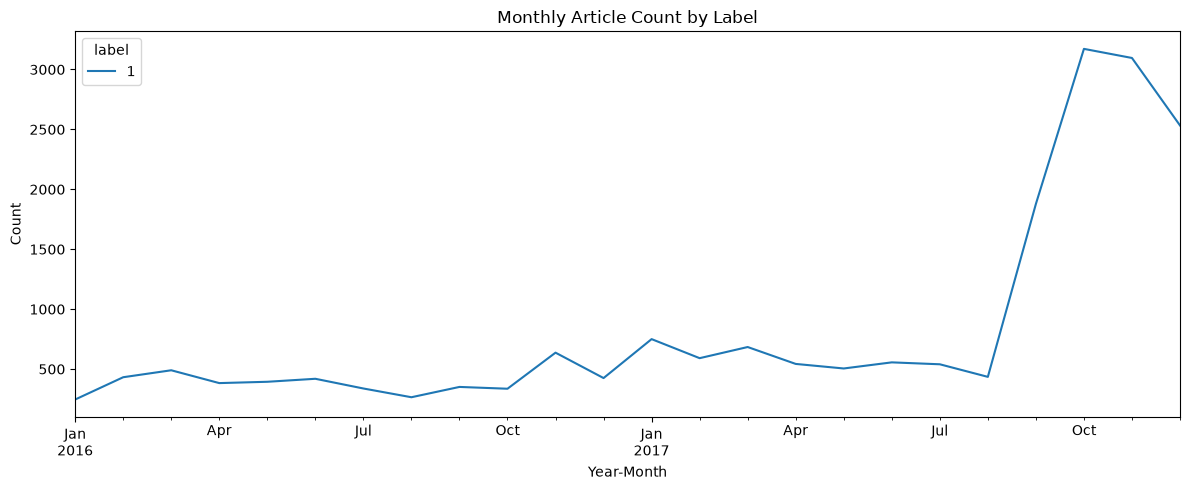

In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Unparseable dates:", df['date'].isna().sum())

plt.figure(figsize=(12, 5))
df.groupby(df['date'].dt.to_period('M'))['label'].value_counts().unstack().plot(ax=plt.gca())
plt.title('Monthly Article Count by Label')
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 6. Text Length Distribution

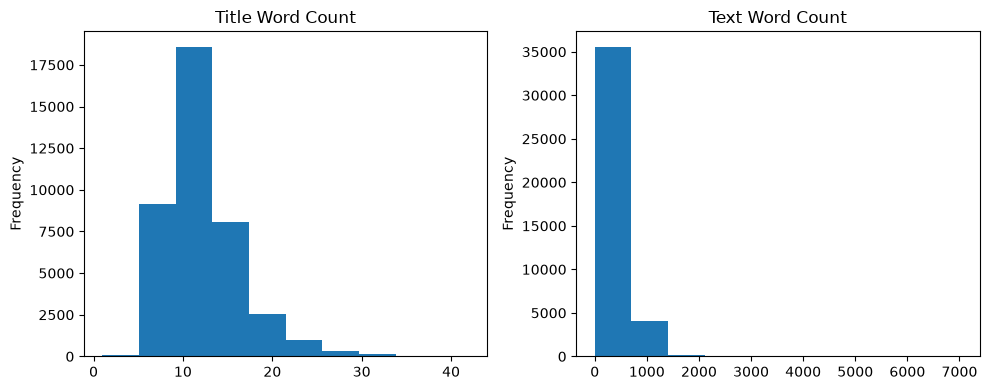

In [9]:
df['title_len'] = df['title'].str.split().apply(len)
df['text_len'] = df['text'].str.split().apply(len)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df['title_len'].plot.hist(ax=ax[0], bins=10)
ax[0].set_title('Title Word Count')

df['text_len'].plot.hist(ax=ax[1], bins=10)
ax[1].set_title('Text Word Count')

plt.tight_layout()
plt.show()


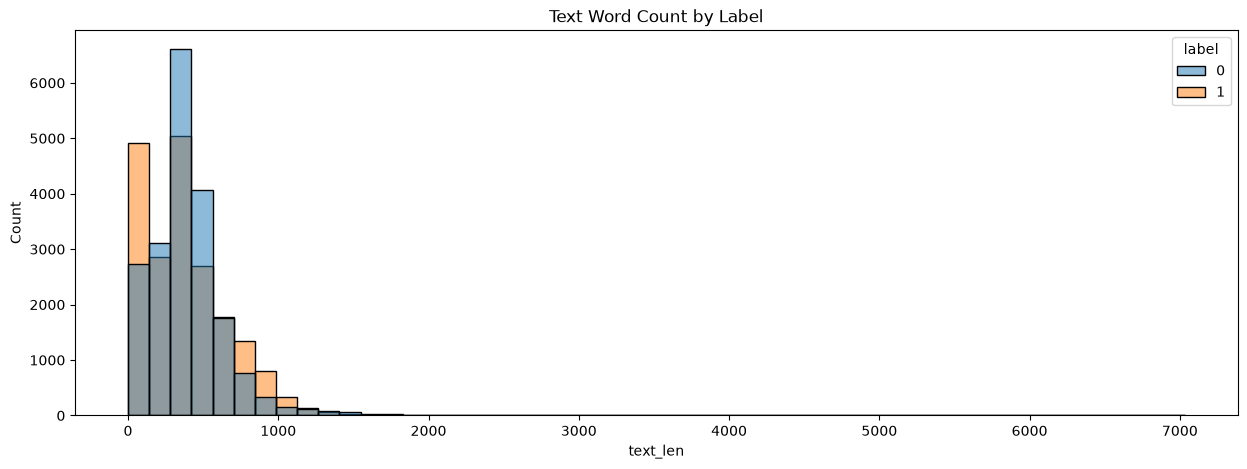

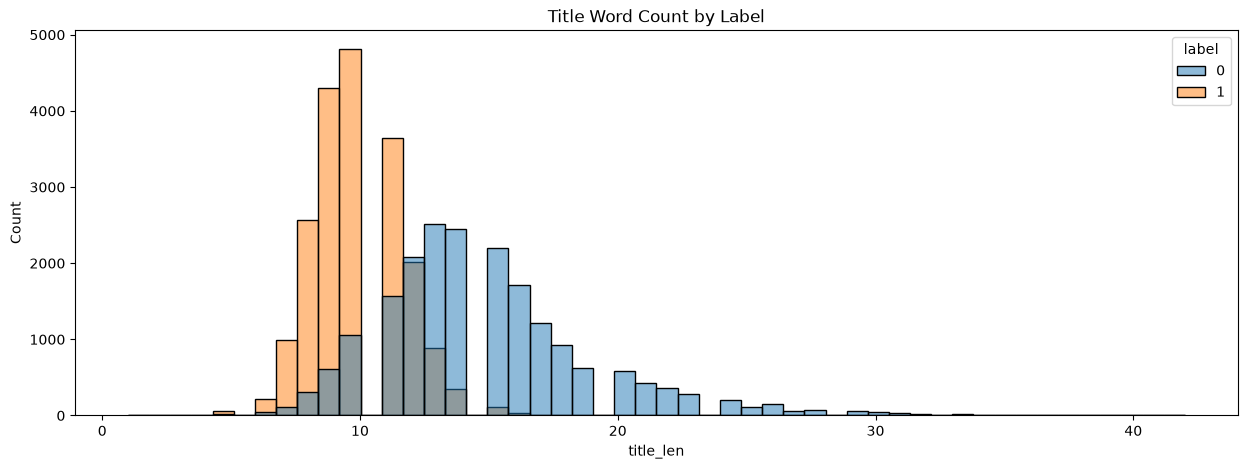

In [10]:
# Word count distribution split by label -- larger figure since range is wide
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='text_len', hue='label', bins=50)
plt.title('Text Word Count by Label')
plt.show()

plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='title_len', hue='label', bins=50)
plt.title('Title Word Count by Label')
plt.show()


### Very short text / title — closer look

Rows with near-empty `text` or a 1-word `title` are worth inspecting individually —
they may be low-content/junk rows rather than genuine short headlines.

In [11]:
# Rows with very little article text
short_text = df[df['text_len'] < 10]
print("Rows with text_len < 10:", len(short_text))
short_text['label'].value_counts()


Rows with text_len < 10: 823


label
0    822
1      1
Name: count, dtype: int64

In [12]:
# Rows with a 1-word title
one_word_title = df[df['title_len'] == 1]
print("Rows with title_len == 1:", len(one_word_title))
one_word_title['label'].value_counts()


Rows with title_len == 1: 8


label
0    8
Name: count, dtype: int64

In [13]:
# Example of a 1-word-title row
one_word_title['text'].iloc[0]


'https://100percentfedup.com/served-roy-moore-vietnamletter-veteran-sets-record-straight-honorable-decent-respectable-patriotic-commander-soldier/'

## 7. Duplicate Check

In [14]:
duplicate_mask = df.duplicated(subset=['title', 'text'], keep=False)
print("Rows involved in title+text duplicates:", duplicate_mask.sum())

df[duplicate_mask].sort_values(['title', 'text']).head(10)


Rows involved in title+text duplicates: 6885


,label,title,text,subject,date,title_len,text_len
29840,0,#Austin: Fights Break Out Between Police and S...,Commies carrying flags fought with the Austin ...,politics,NaT,10,241
37929,0,#Austin: Fights Break Out Between Police and S...,Commies carrying flags fought with the Austin ...,left-news,NaT,10,241
31755,0,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,Is anyone else thinking what we re thinking ab...,politics,NaT,12,70
39210,0,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,Is anyone else thinking what we re thinking ab...,left-news,NaT,12,70
31754,0,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Smashing windows How progressive!Protests aga...,politics,NaT,9,44
39209,0,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Smashing windows How progressive!Protests aga...,left-news,NaT,9,44
31677,0,#BoycottGrammys… #TurnOffTheGrammys…Grammys Pr...,In a fraught moment of political protest acros...,politics,NaT,15,254
39146,0,#BoycottGrammys… #TurnOffTheGrammys…Grammys Pr...,In a fraught moment of political protest acros...,left-news,NaT,15,254
32238,0,"#BoycottPenzeys: HATEFUL, DIVISIVE Penzeys Spi...","Bill Penzey, the owner of Penzeys Spices, wrot...",politics,NaT,19,525
39515,0,"#BoycottPenzeys: HATEFUL, DIVISIVE Penzeys Spi...","Bill Penzey, the owner of Penzeys Spices, wrot...",left-news,NaT,19,525


## 8. Conclusions & Feature Decisions

- **Drop `subject`** — subjects map almost entirely to one label or the other (clear data
  leak).
- **Drop `date`** — not clearly relevant to genuine fake/real distinction, and some dates
  fail to parse.
- **Keep empty/short `text` and `title` rows for now** — not dropping now, since
  the empty text may itself carry signal (e.g. `text_len == 0` rows are
  overwhelmingly fake news in this dataset — only one real-news row has empty text).
  Fill with empty strings rather than dropping, and revisit later if this hurts performance.
- **Duplicates**: found duplicate rows on `title` + `text`. No changes done.
